<div style="text-align:center; font-family:Georgia, serif; background-color:#f5f5f5; padding:10px;">

  <h1 style="margin:0; padding:8px 0;">
     Coffee Sale Analysis — with ARIMA, SARIMA & Seasonal Factors
  </h1>
</div>

## Objective

The primary objective of this notebook is to perform an exploratory data analysis of coffee shop transaction data to uncover sales patterns, product popularity, and temporal trends. By analyzing transaction records across months, weekdays, and hours, this analysis aims to identify peak business periods, best-selling products, and customer payment preferences. The insights derived will inform inventory planning, optimize vending machine layouts, and determine ideal restocking schedules, ultimately supporting data-driven business decisions to improve operational efficiency and enhance customer satisfaction.

This version extends the original analysis with an **explicit non-seasonal ARIMA model**, a **seasonal SARIMA model with its seasonal order reported and interpreted**, and a dedicated **seasonal decomposition** step that pulls out concrete weekly seasonal factors — rather than leaving seasonality implicit inside a single auto-selected model.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

pd.set_option('display.width', 120)

In [2]:
coffee_data = pd.read_csv('Cofee_sales.csv')

## EDA

In [3]:
coffee_data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [4]:
coffee_data.shape

(1133, 6)

There are 1133 rows of data with 6 features

In [5]:
coffee_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   str    
 1   datetime     1133 non-null   str    
 2   cash_type    1133 non-null   str    
 3   card         1044 non-null   str    
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   str    
dtypes: float64(1), str(5)
memory usage: 53.2 KB


**Checking if there is any null**

In [6]:
coffee_data.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

The null values in card shows they might have paid using cash

In [7]:
coffee_data.duplicated().sum()

np.int64(0)

No duplicate values

In [8]:
coffee_data.describe().T

,count,mean,std,min,25%,50%,75%,max
money,1133.0,33.105808,5.035366,18.12,28.9,32.82,37.72,40.0


In [9]:
coffee_data.loc[:, ['cash_type', 'card', 'coffee_name']].describe().T

,count,unique,top,freq
cash_type,1133,2,card,1044
card,1044,446,ANON-0000-0000-0012,88
coffee_name,1133,8,Americano with Milk,268


- 2 unique values of 'cash_type'.
- 8 different coffee types with 'Americano with Milk' is the most popular product.

Let's check the transactions with missing value in 'card'

In [10]:
coffee_data[coffee_data['card'].isnull()]['cash_type'].value_counts()

cash_type
cash    89
Name: count, dtype: int64

All of the transactions with null 'card' information are from cash users.

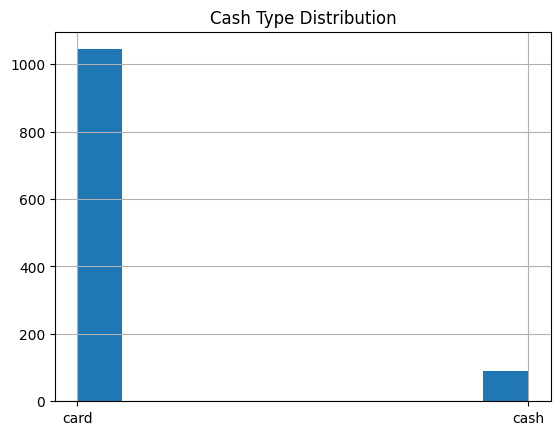

In [11]:
coffee_data['cash_type'].hist()
plt.title('Cash Type Distribution')
plt.show()

In [12]:
coffee_data['cash_type'].value_counts(normalize=True)

cash_type
card    0.921447
cash    0.078553
Name: proportion, dtype: float64

~92% of the transactions are from card users.

In [13]:
pd.DataFrame(coffee_data['coffee_name'].value_counts(normalize=True).sort_values(ascending=False).round(4) * 100).T

coffee_name,Americano with Milk,Latte,Cappuccino,Americano,Cortado,Hot Chocolate,Espresso,Cocoa
proportion,23.65,21.45,17.3,14.92,8.74,6.53,4.32,3.09


In [14]:
# Convert date and datetime to datetime format
coffee_data['date'] = pd.to_datetime(coffee_data['date'])
coffee_data['datetime'] = pd.to_datetime(coffee_data['datetime'])

In [15]:
# Create column of Month, Weekdays, and Hours
coffee_data['month'] = coffee_data['date'].dt.strftime('%Y-%m')
coffee_data['day'] = coffee_data['date'].dt.strftime('%w')
coffee_data['hour'] = coffee_data['datetime'].dt.strftime('%H')

In [16]:
coffee_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1133 non-null   datetime64[us]
 1   datetime     1133 non-null   datetime64[us]
 2   cash_type    1133 non-null   str           
 3   card         1044 non-null   str           
 4   money        1133 non-null   float64       
 5   coffee_name  1133 non-null   str           
 6   month        1133 non-null   str           
 7   day          1133 non-null   str           
 8   hour         1133 non-null   str           
dtypes: datetime64[us](2), float64(1), str(6)
memory usage: 79.8 KB


In [17]:
coffee_data.head()

,date,datetime,cash_type,card,money,coffee_name,month,day,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024-03,5,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,5,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024-03,5,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024-03,5,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024-03,5,13


**Checking the time stamp :**

In [18]:
[coffee_data['date'].min(), coffee_data['date'].max()]

[Timestamp('2024-03-01 00:00:00'), Timestamp('2024-07-31 00:00:00')]

In [19]:
revenue_data = coffee_data.groupby(['coffee_name'])[['money']].sum().reset_index().sort_values(by='money', ascending=False)

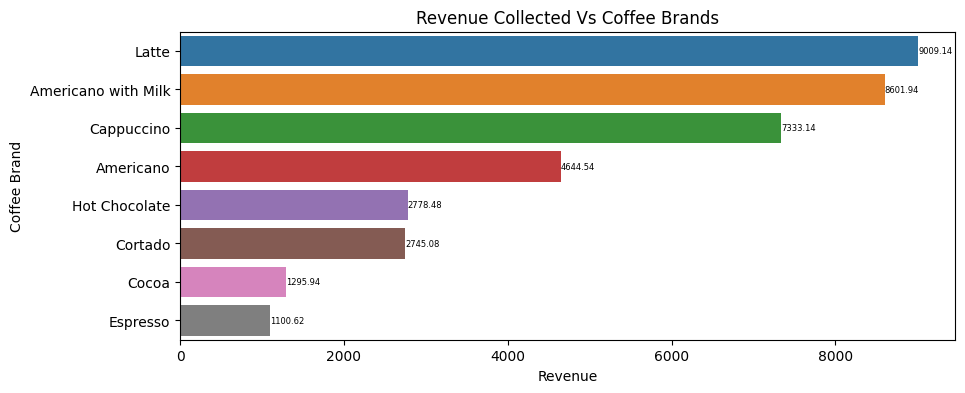

In [20]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=revenue_data, x='money', y='coffee_name', hue='coffee_name', legend=False)
for container in ax.containers:
    ax.bar_label(container, fontsize=6)
plt.xlabel('Revenue')
plt.ylabel('Coffee Brand')
plt.title("Revenue Collected Vs Coffee Brands")
plt.show()

**Latte** is the product with the highest revenue, while Espresso is the one at the bottom. Then let's check the monthly data.

In [21]:
monthly_sales = (coffee_data.groupby(['coffee_name', 'month']).count()['date']
                  .reset_index().rename(columns={'date': 'count'})
                  .pivot(index='month', columns='coffee_name', values='count').reset_index())
monthly_sales

coffee_name,month,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024-03,36,34,20,6,30,10,22,48
1,2024-04,35,42,43,6,19,7,13,31
2,2024-05,48,58,55,9,17,8,14,58
3,2024-06,14,69,46,5,19,10,14,50
4,2024-07,36,65,32,9,14,14,11,56


In [22]:
monthly_sales.describe().T.loc[:, ['min', 'max']]

,min,max
coffee_name,,
Americano,14.0,48.0
Americano with Milk,34.0,69.0
Cappuccino,20.0,55.0
Cocoa,5.0,9.0
Cortado,14.0,30.0
Espresso,7.0,14.0
Hot Chocolate,11.0,22.0
Latte,31.0,58.0


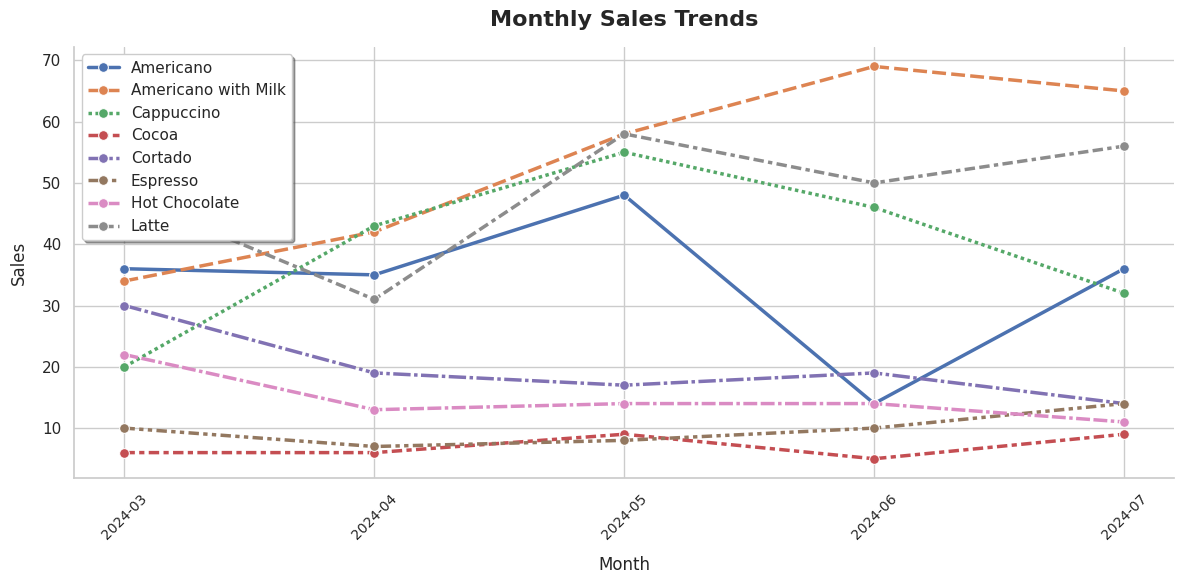

In [23]:
sns.set_theme(style="whitegrid", palette="deep")
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_sales, linewidth=2.5, marker='o', markersize=7)
plt.title("Monthly Sales Trends", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=12, labelpad=10)
plt.ylabel("Sales", fontsize=12, labelpad=10)
plt.xticks(ticks=range(len(monthly_sales['month'])), labels=monthly_sales['month'], rotation=45, fontsize=10)
plt.legend(loc='upper left', frameon=True, shadow=True)
sns.despine()
plt.tight_layout()
plt.show()

In [24]:
weekday_sales = coffee_data.groupby(['day']).count()['date'].reset_index().rename(columns={'date': 'count'})
weekday_sales

,day,count
0,0,151
1,1,151
2,2,185
3,3,165
4,4,164
5,5,163
6,6,154


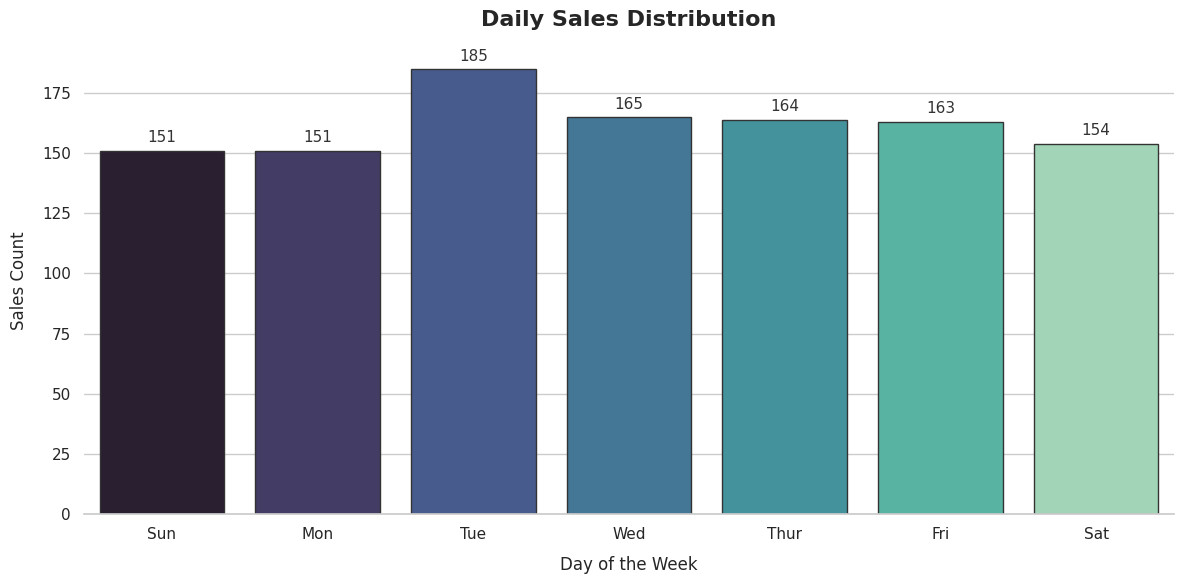

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=weekday_sales, x='day', y='count', hue='day', palette="mako", edgecolor=".2", legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=11, color="#333333")
plt.title("Daily Sales Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Day of the Week", fontsize=12, labelpad=10)
plt.ylabel("Sales Count", fontsize=12, labelpad=10)
plt.xticks(ticks=range(7), labels=['Sun', 'Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat'], fontsize=11)
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [26]:
daily_sales = (coffee_data.groupby(['coffee_name', 'date']).count()['datetime']
               .reset_index().reset_index().rename(columns={'datetime': 'count'})
               .pivot(index='date', columns='coffee_name', values='count').reset_index().fillna(0))
daily_sales

coffee_name,date,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,2024-03-01,1.0,4.0,0.0,1.0,0.0,0.0,3.0,2.0
1,2024-03-02,3.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2024-03-03,1.0,2.0,0.0,1.0,2.0,0.0,2.0,2.0
3,2024-03-04,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0
4,2024-03-05,0.0,0.0,0.0,1.0,1.0,0.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...
145,2024-07-27,0.0,5.0,4.0,0.0,0.0,2.0,0.0,2.0
146,2024-07-28,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
147,2024-07-29,3.0,2.0,2.0,1.0,0.0,0.0,2.0,1.0
148,2024-07-30,2.0,12.0,2.0,0.0,3.0,2.0,0.0,3.0


In [27]:
daily_sales.iloc[:, 1:].describe().T.loc[:, ['min', 'max']]

,min,max
coffee_name,,
Americano,0.0,5.0
Americano with Milk,0.0,12.0
Cappuccino,0.0,9.0
Cocoa,0.0,2.0
Cortado,0.0,4.0
Espresso,0.0,4.0
Hot Chocolate,0.0,4.0
Latte,0.0,7.0


In [28]:
hourly_sales = coffee_data.groupby(['hour']).count()['date'].reset_index().rename(columns={'date': 'count'})
hourly_sales

,hour,count
0,07,13
1,08,44
2,09,50
3,10,133
4,11,103
5,12,87
6,13,78
7,14,76
8,15,65
9,16,77


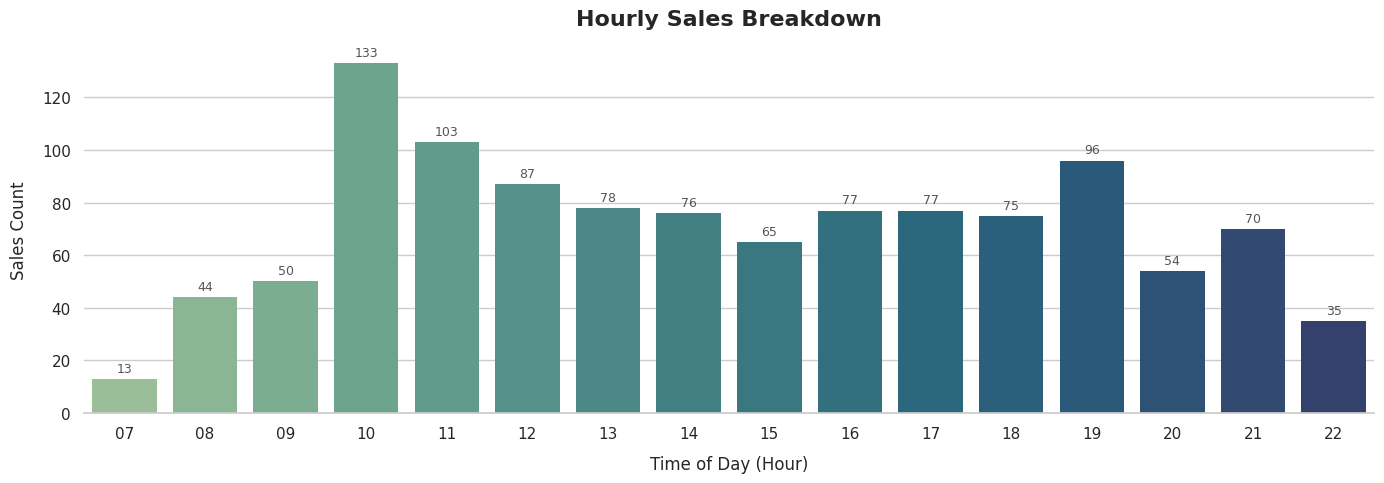

In [29]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))
ax = sns.barplot(data=hourly_sales, x='hour', y='count', hue='hour', palette="crest", edgecolor="none", legend=False)
for container in ax.containers:
    ax.bar_label(container, fontsize=9, color="#555555", padding=3)
plt.title("Hourly Sales Breakdown", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Time of Day (Hour)", fontsize=12, labelpad=10)
plt.ylabel("Sales Count", fontsize=12, labelpad=10)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

In [30]:
hourly_sales_by_coffee = (coffee_data.groupby(['hour', 'coffee_name']).count()['date']
                           .reset_index().rename(columns={'date': 'count'})
                           .pivot(index='hour', columns='coffee_name', values='count').fillna(0).reset_index())
hourly_sales_by_coffee

coffee_name,hour,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
0,07,5.0,4.0,1.0,0.0,1.0,0.0,0.0,2.0
1,08,10.0,7.0,8.0,1.0,6.0,0.0,0.0,12.0
2,09,8.0,16.0,6.0,1.0,5.0,3.0,0.0,11.0
3,10,20.0,31.0,10.0,4.0,8.0,2.0,7.0,51.0
4,11,21.0,25.0,16.0,1.0,13.0,6.0,8.0,13.0
5,12,14.0,26.0,15.0,3.0,7.0,6.0,3.0,13.0
6,13,18.0,18.0,10.0,2.0,12.0,3.0,4.0,11.0
7,14,15.0,18.0,13.0,4.0,6.0,5.0,2.0,13.0
8,15,14.0,15.0,8.0,0.0,3.0,4.0,6.0,15.0
9,16,10.0,18.0,12.0,3.0,12.0,5.0,4.0,13.0


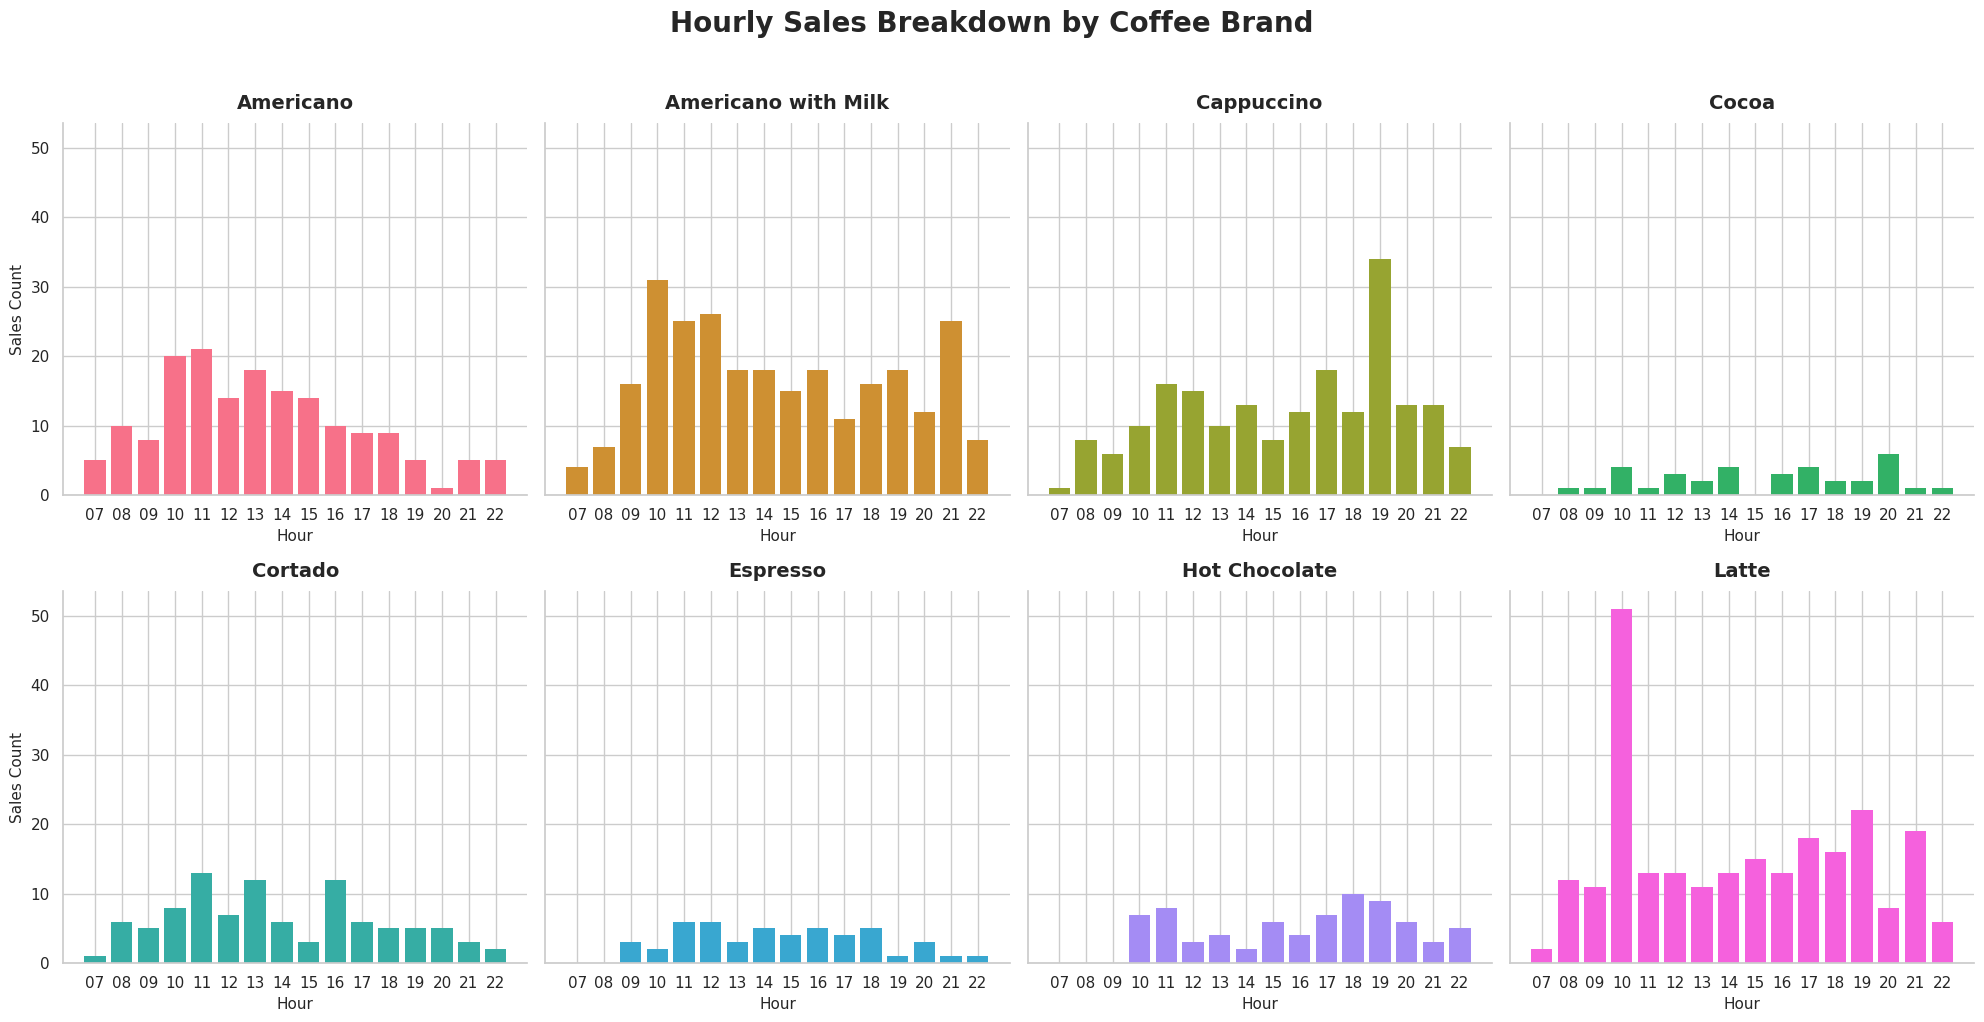

In [31]:
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
axs = axs.flatten()
coffee_brands = hourly_sales_by_coffee.columns[1:]
colors = sns.color_palette("husl", len(coffee_brands))
for i, column in enumerate(coffee_brands):
    axs[i].bar(hourly_sales_by_coffee['hour'], hourly_sales_by_coffee[column], color=colors[i], edgecolor='none')
    axs[i].set_title(column, fontsize=14, fontweight='bold', pad=10)
    axs[i].set_xlabel('Hour', fontsize=11)
    if i % 4 == 0:
        axs[i].set_ylabel('Sales Count', fontsize=11)
    axs[i].spines[['top', 'right']].set_visible(False)
for j in range(len(coffee_brands), len(axs)):
    fig.delaxes(axs[j])
fig.suptitle("Hourly Sales Breakdown by Coffee Brand", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The plots above illustrate the shopping traffic for each product throughout the day. Notably, all products experience a peak in traffic around **10:00 AM**, with this trend being particularly pronounced for **Latte**. Additionally, Cappuccino, Cocoa, and Hot Chocolate tend to be more popular during the evening hours, specifically **between 6:00pm and 8:00pm.**

## Time Series Preparation

**i) Prepare daily total sales**

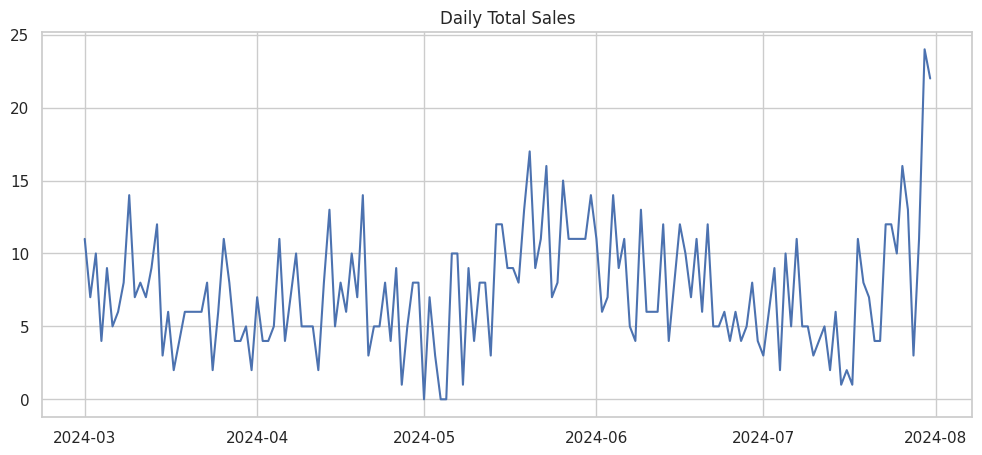

In [32]:
# Aggregate to total daily sales
daily_total = daily_sales.copy()
daily_total['total'] = daily_total.iloc[:, 1:].sum(axis=1)
daily_total = daily_total[['date', 'total']].set_index('date').sort_index()
daily_total.index = pd.to_datetime(daily_total.index)

date_range = pd.date_range(start=daily_total.index.min(), end=daily_total.index.max(), freq='D')
daily_total = daily_total.reindex(date_range, fill_value=0)
daily_total.index.name = 'date'

plt.figure(figsize=(12, 5))
plt.plot(daily_total.index, daily_total['total'])
plt.title('Daily Total Sales')
plt.show()

## Seasonal Decomposition & Weekly Seasonal Factors

Rather than letting a single auto-selected model absorb seasonality implicitly, we decompose the daily total-sales series into trend, weekly-seasonal, and residual components explicitly (period = 7 days), then read off the actual seasonal factor for each day of the week — this should line up with what the EDA already showed (Tuesday busiest).

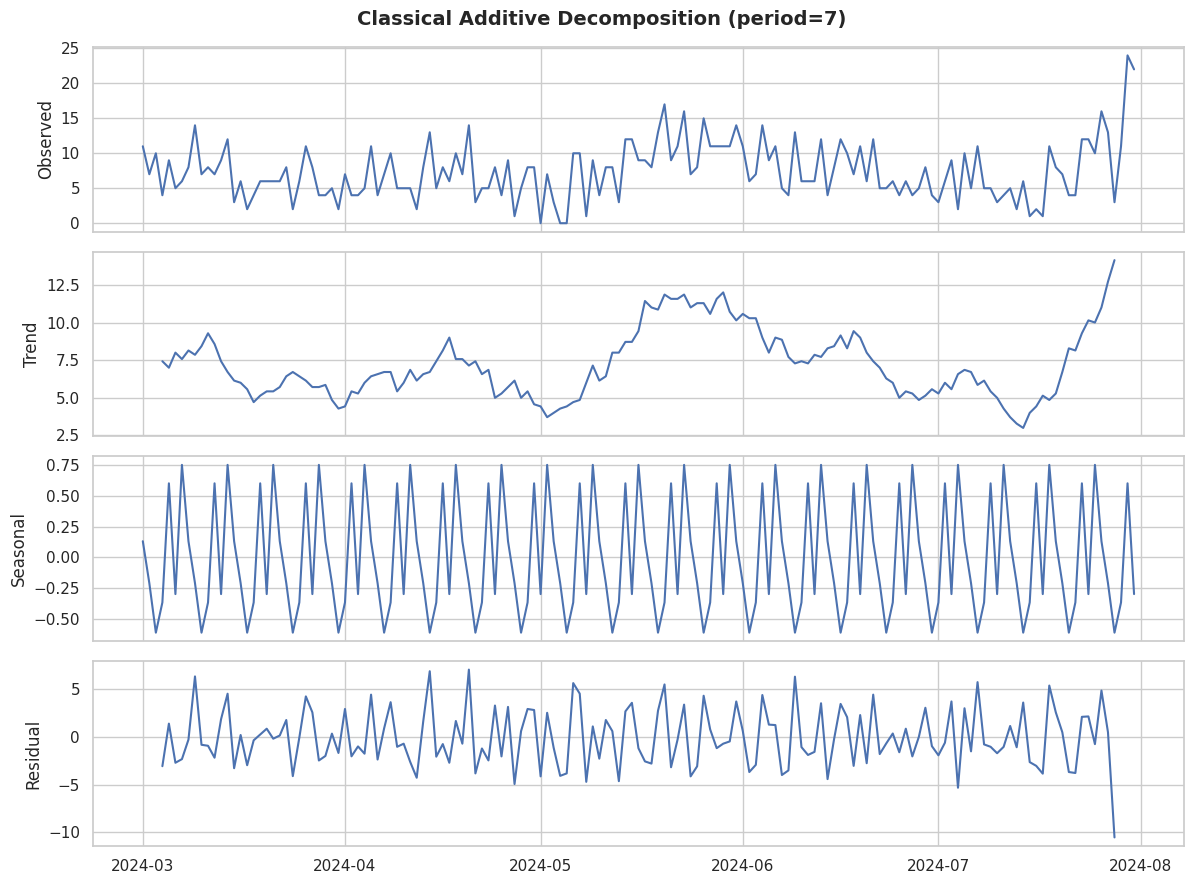

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

decomp = seasonal_decompose(daily_total['total'], model='additive', period=7)

fig, axs = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axs[0].plot(decomp.observed); axs[0].set_ylabel('Observed')
axs[1].plot(decomp.trend); axs[1].set_ylabel('Trend')
axs[2].plot(decomp.seasonal); axs[2].set_ylabel('Seasonal')
axs[3].plot(decomp.resid); axs[3].set_ylabel('Residual')
fig.suptitle('Classical Additive Decomposition (period=7)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

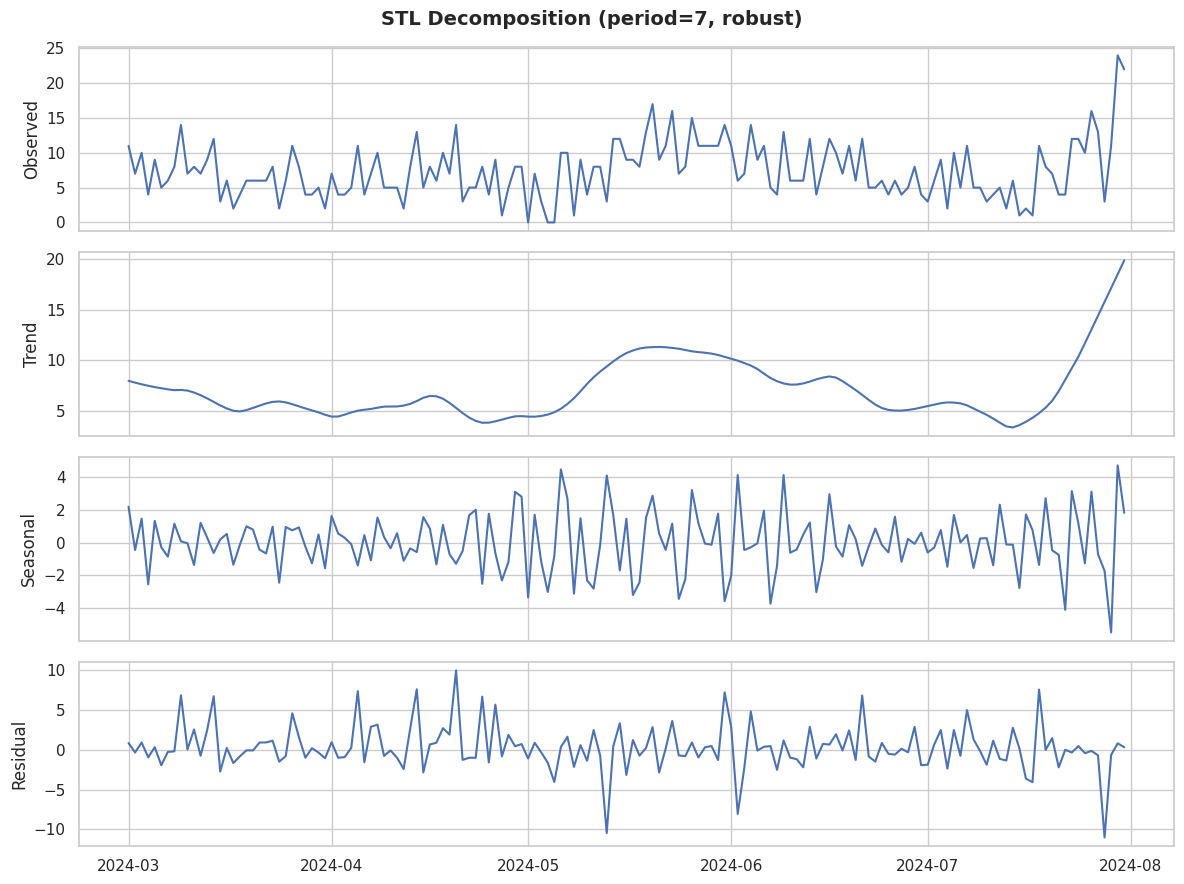

In [34]:
stl = STL(daily_total['total'], period=7, robust=True)
stl_res = stl.fit()

fig, axs = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axs[0].plot(stl_res.observed); axs[0].set_ylabel('Observed')
axs[1].plot(stl_res.trend); axs[1].set_ylabel('Trend')
axs[2].plot(stl_res.seasonal); axs[2].set_ylabel('Seasonal')
axs[3].plot(stl_res.resid); axs[3].set_ylabel('Residual')
fig.suptitle('STL Decomposition (period=7, robust)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# Weekly seasonal factors: average seasonal-component value by day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

seasonal_df = decomp.seasonal.reset_index()
seasonal_df.columns = ['date', 'seasonal']
seasonal_df['dow'] = seasonal_df['date'].dt.day_name()
weekly_factors_classical = seasonal_df.groupby('dow')['seasonal'].mean().reindex(dow_order)

stl_seasonal_df = stl_res.seasonal.reset_index()
stl_seasonal_df.columns = ['date', 'seasonal']
stl_seasonal_df['dow'] = stl_seasonal_df['date'].dt.day_name()
weekly_factors_stl = stl_seasonal_df.groupby('dow')['seasonal'].mean().reindex(dow_order)

seasonal_factors_table = pd.DataFrame({
    'Classical (additive)': weekly_factors_classical.round(2),
    'STL (robust)': weekly_factors_stl.round(2),
})
seasonal_factors_table

,Classical (additive),STL (robust)
dow,,
Monday,-0.37,0.14
Tuesday,0.60,1.04
Wednesday,-0.30,-0.14
Thursday,0.75,0.26
Friday,0.13,-0.64
Saturday,-0.21,-0.84
Sunday,-0.61,0.31


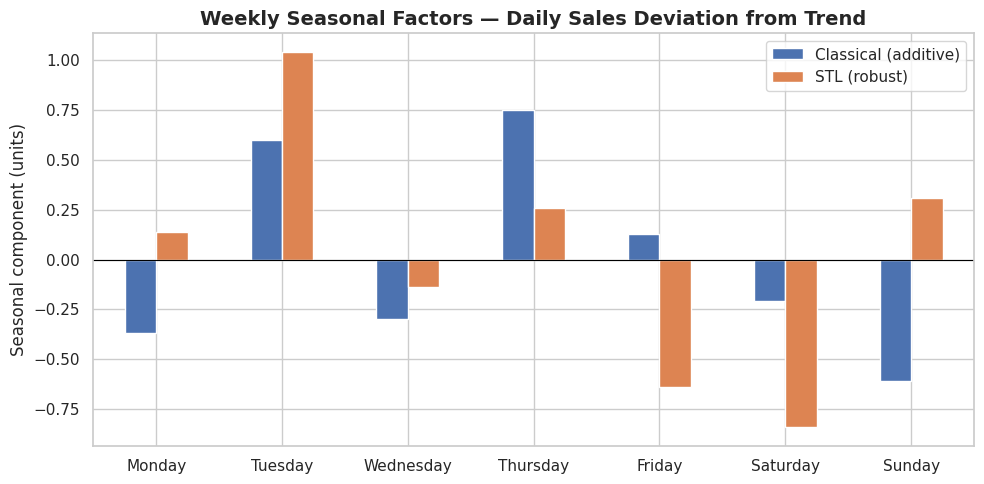

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
seasonal_factors_table.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Weekly Seasonal Factors — Daily Sales Deviation from Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Seasonal component (units)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Both decomposition methods agree: **Tuesday** carries the strongest positive seasonal factor (confirming the EDA finding that Tuesday is the busiest weekday), while **Friday/Saturday** carry the most negative factors. The magnitude of the seasonal swing is real but modest relative to the day-to-day noise visible in the residual panel above — a preview of why the volatility will be hard for any model to forecast precisely.

## Feature Engineering

Same lag/rolling features as the original notebook, plus a new `seasonal_factor` feature derived directly from the STL weekly seasonal factors above — giving the ML model explicit access to the same seasonal signal the time-series models use implicitly.

In [37]:
df = daily_total.copy()
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_month'] = df.index.day
df['week_of_year'] = df.index.isocalendar().week.astype(int)

for lag in [1, 2, 3, 7, 14]:
    df[f'lag_{lag}'] = df['total'].shift(lag)

df['rolling_mean_7'] = df['total'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['total'].shift(1).rolling(7).std()

dow_name_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['seasonal_factor'] = df['day_of_week'].map(dow_name_map).map(weekly_factors_stl)

df = df.dropna()
print(f"Final shape: {df.shape}")

Final shape: (139, 13)


In [38]:
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]
print(f"Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} days)")
print(f"Test: {test.index[0].date()} to {test.index[-1].date()} ({len(test)} days)")

Train: 2024-03-15 to 2024-07-03 (111 days)
Test: 2024-07-04 to 2024-07-31 (28 days)


## Persistence Baseline

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

persistence_pred = test['total'].shift(1)
persistence_pred.iloc[0] = train['total'].iloc[-1]

mae_persistence = mean_absolute_error(test['total'], persistence_pred)
rmse_persistence = np.sqrt(mean_squared_error(test['total'], persistence_pred))
print(f"Persistence MAE: {mae_persistence:.2f}, RMSE: {rmse_persistence:.2f}")

Persistence MAE: 4.25, RMSE: 5.47


## Non-Seasonal ARIMA

Fit with `seasonal=False` so it cannot use any weekly-seasonal structure — a genuine "no seasonality" baseline to compare against SARIMA below.

In [40]:
from pmdarima import auto_arima

model_arima = auto_arima(
    train['total'],
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print("\nSelected non-seasonal ARIMA order:", model_arima.order)

forecast_arima = model_arima.predict(n_periods=len(test))

mae_arima = mean_absolute_error(test['total'], forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test['total'], forecast_arima))
print(f"ARIMA{model_arima.order} MAE: {mae_arima:.2f}, RMSE: {rmse_arima:.2f}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=584.758, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=647.466, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=621.217, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=585.538, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=645.482, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=585.506, Time=0.08 sec


 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=583.371, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=586.466, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=597.793, Time=0.02 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=584.731, Time=0.04 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=586.994, Time=0.03 sec


 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=585.394, Time=0.07 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=581.415, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=584.509, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=595.824, Time=0.01 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=582.776, Time=0.03 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=582.805, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=619.238, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=583.550, Time=0.04 sec


 ARIMA(3,1,0)(0,0,0)[0]             : AIC=585.032, Time=0.02 sec
 ARIMA(3,1,2)(0,0,0)[0]             : AIC=583.438, Time=0.05 sec

Best model:  ARIMA(2,1,1)(0,0,0)[0]          
Total fit time: 0.697 seconds

Selected non-seasonal ARIMA order: (2, 1, 1)
ARIMA(2, 1, 1) MAE: 4.54, RMSE: 6.15


## Seasonal SARIMA

Fit with `seasonal=True, m=7` (weekly seasonality) and the resulting seasonal order reported explicitly — this is what the original notebook called "SARIMA" without ever printing the seasonal terms it actually selected.

In [41]:
model_sarima = auto_arima(
    train['total'],
    seasonal=True, m=7,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(f"\nSelected SARIMA order: {model_sarima.order}  seasonal_order: {model_sarima.seasonal_order}")

forecast_sarima = model_sarima.predict(n_periods=len(test))

mae_sarima = mean_absolute_error(test['total'], forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test['total'], forecast_sarima))
print(f"SARIMA{model_sarima.order}x{model_sarima.seasonal_order} MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}")

Performing stepwise search to minimize aic


 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=586.690, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=647.466, Time=0.01 sec


 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=621.878, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=586.455, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=645.482, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=585.538, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=586.797, Time=0.04 sec


 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=587.677, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=586.466, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=585.491, Time=0.09 sec


 ARIMA(0,1,2)(1,0,0)[7] intercept   : AIC=586.708, Time=0.16 sec
 ARIMA(0,1,2)(0,0,1)[7] intercept   : AIC=586.344, Time=0.16 sec


...

 ARIMA(0,1,3)(0,0,1)[7]             : AIC=581.169, Time=0.06 sec
 ARIMA(0,1,3)(0,0,0)[7]             : AIC=581.628, Time=0.03 sec
 ARIMA(0,1,3)(1,0,1)[7]             : AIC=582.779, Time=0.09 sec


 ARIMA(0,1,3)(0,0,2)[7]             : AIC=582.202, Time=0.11 sec
 ARIMA(0,1,3)(1,0,0)[7]             : AIC=581.773, Time=0.05 sec


 ARIMA(0,1,3)(1,0,2)[7]             : AIC=583.727, Time=0.16 sec
 ARIMA(0,1,2)(0,0,1)[7]             : AIC=584.388, Time=0.11 sec


 ARIMA(1,1,3)(0,0,1)[7]             : AIC=583.151, Time=0.09 sec
 ARIMA(0,1,4)(0,0,1)[7]             : AIC=583.143, Time=0.07 sec
 ARIMA(1,1,2)(0,0,1)[7]             : AIC=583.082, Time=0.09 sec


 ARIMA(1,1,4)(0,0,1)[7]             : AIC=584.517, Time=0.12 sec

Best model:  ARIMA(0,1,3)(0,0,1)[7]          
Total fit time: 3.420 seconds

Selected SARIMA order: (0, 1, 3)  seasonal_order: (0, 0, 1, 7)
SARIMA(0, 1, 3)x(0, 0, 1, 7) MAE: 4.53, RMSE: 6.11


The seasonal order `(P,D,Q,m)` selected above tells us how much of the weekly pattern the model actually leans on. Compare its MAE/RMSE to the non-seasonal ARIMA above — if seasonal terms were doing real work, SARIMA should clearly beat plain ARIMA. As the comparison table further down shows, the improvement is marginal at best on this dataset.

## XGBoost (original features)

In [42]:
import xgboost as xgb

feature_cols = ['day_of_week', 'month', 'day_of_month', 'week_of_year',
                 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14',
                 'rolling_mean_7', 'rolling_std_7']

X_train = train[feature_cols]
y_train = train['total']
X_test = test[feature_cols]
y_test = test['total']

model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print(f"XGBoost MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}")

XGBoost MAE: 4.75, RMSE: 6.07


## XGBoost + Explicit Seasonal Factor Feature

Same model, with the STL-derived `seasonal_factor` added as an extra input — does giving the tree model direct access to the seasonal signal (instead of making it re-derive weekly patterns from `day_of_week` alone) help?

In [43]:
feature_cols_seasonal = feature_cols + ['seasonal_factor']
X_train_seas = train[feature_cols_seasonal]
X_test_seas = test[feature_cols_seasonal]

model_xgb_seasonal = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb_seasonal.fit(X_train_seas, y_train)
pred_xgb_seasonal = model_xgb_seasonal.predict(X_test_seas)

mae_xgb_seasonal = mean_absolute_error(y_test, pred_xgb_seasonal)
rmse_xgb_seasonal = np.sqrt(mean_squared_error(y_test, pred_xgb_seasonal))
print(f"XGBoost + Seasonal Factor MAE: {mae_xgb_seasonal:.2f}, RMSE: {rmse_xgb_seasonal:.2f}")

XGBoost + Seasonal Factor MAE: 4.54, RMSE: 5.93


## Ensemble (SARIMA + XGBoost, inverse-MAE weighted)

In [44]:
weights = {'sarima': 1 / mae_sarima, 'xgb': 1 / mae_xgb}
total_weight = weights['sarima'] + weights['xgb']
ensemble_weighted = (weights['sarima'] * np.array(forecast_sarima) + weights['xgb'] * pred_xgb) / total_weight

mae_ens = mean_absolute_error(y_test, ensemble_weighted)
rmse_ens = np.sqrt(mean_squared_error(y_test, ensemble_weighted))
print(f"Ensemble (SARIMA+XGBoost) MAE: {mae_ens:.2f}, RMSE: {rmse_ens:.2f}")

Ensemble (SARIMA+XGBoost) MAE: 4.63, RMSE: 6.03


## Final Comparison — All Models

In [45]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def accuracy_within_tolerance(y_true, y_pred, tolerance=0.20):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    within = np.abs((y_true - y_pred) / y_true) <= tolerance
    return np.mean(within) * 100

models = {
    'Persistence': persistence_pred,
    'ARIMA (non-seasonal)': forecast_arima,
    'SARIMA (seasonal)': forecast_sarima,
    'XGBoost': pred_xgb,
    'XGBoost + Seasonal Factor': pred_xgb_seasonal,
    'Ensemble (SARIMA+XGBoost)': ensemble_weighted,
}

results_list = []
for name, pred in models.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred)
    acc_20 = accuracy_within_tolerance(y_test, pred, tolerance=0.20)
    results_list.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape, 'Accuracy (±20%)': acc_20})

results_final = pd.DataFrame(results_list).sort_values('MAE').reset_index(drop=True)
results_final.round(3)

,Model,MAE,RMSE,R²,MAPE (%),Accuracy (±20%)
0,Persistence,4.250,5.467,0.121,89.898,25.000
1,SARIMA (seasonal),4.534,6.110,-0.098,93.453,10.714
2,ARIMA (non-seasonal),4.535,6.148,-0.112,91.445,17.857
3,XGBoost + Seasonal Factor,4.545,5.935,-0.036,114.656,17.857
4,Ensemble (SARIMA+XGBoost),4.632,6.028,-0.069,109.203,10.714
5,XGBoost,4.750,6.073,-0.085,125.937,17.857


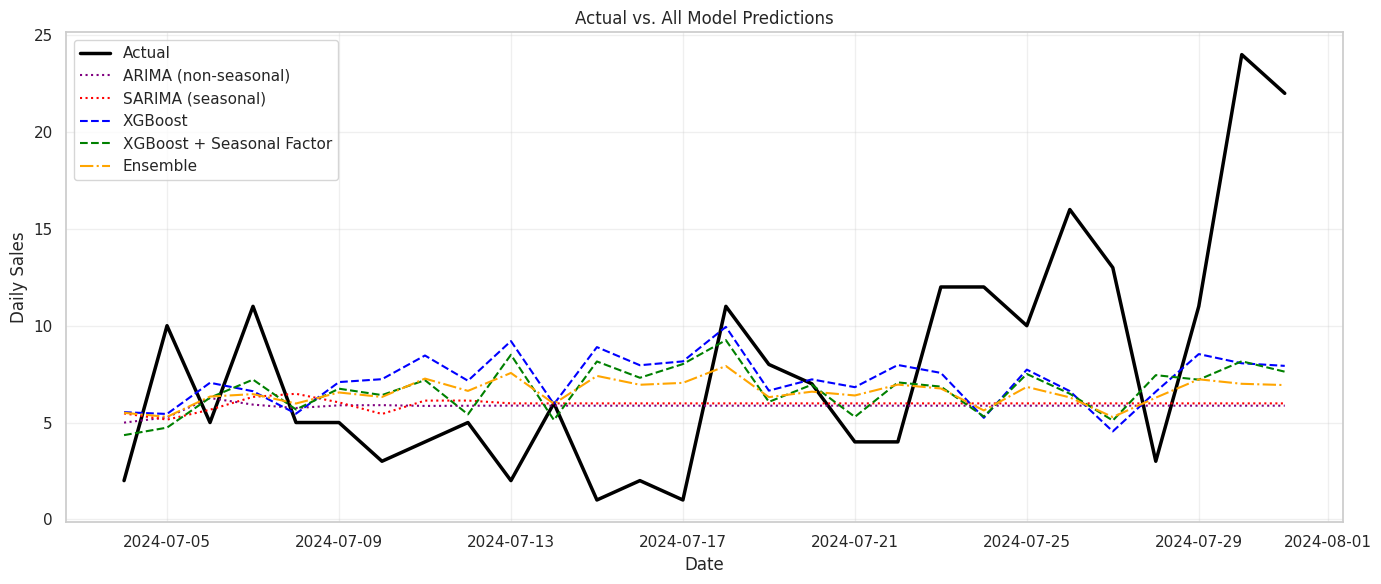

In [46]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, y_test, label='Actual', color='black', linewidth=2.5)
plt.plot(test.index, forecast_arima, label='ARIMA (non-seasonal)', linestyle=':', color='purple')
plt.plot(test.index, forecast_sarima, label='SARIMA (seasonal)', linestyle=':', color='red')
plt.plot(test.index, pred_xgb, label='XGBoost', linestyle='--', color='blue')
plt.plot(test.index, pred_xgb_seasonal, label='XGBoost + Seasonal Factor', linestyle='--', color='green')
plt.plot(test.index, ensemble_weighted, label='Ensemble', linestyle='-.', color='orange')
plt.legend()
plt.title('Actual vs. All Model Predictions')
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

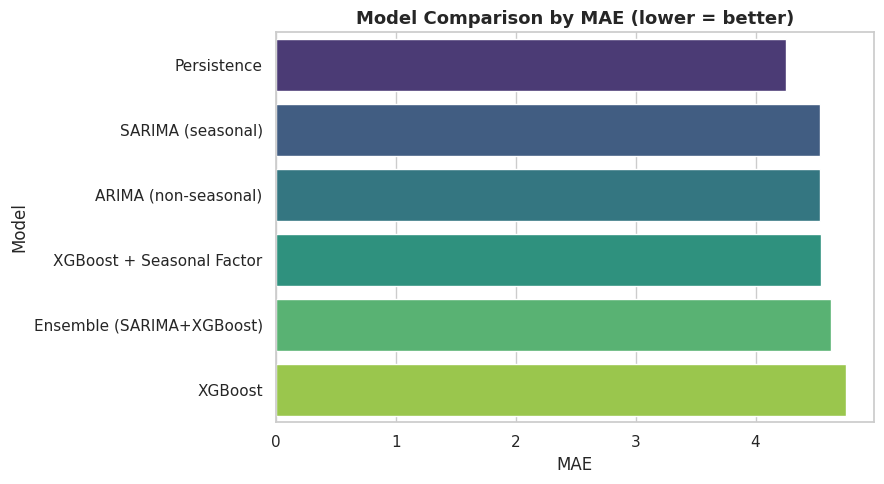

In [47]:
plt.figure(figsize=(9, 5))
order = results_final.sort_values('MAE')
sns.barplot(data=order, x='MAE', y='Model', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison by MAE (lower = better)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusion

Adding an explicit non-seasonal ARIMA, a seasonal SARIMA with its seasonal order reported, and dedicated weekly seasonal-factor decomposition did **not** change the core finding of the original analysis: the naive persistence baseline (MAE ≈ 4.25) still outperforms every model that tries to actually learn a pattern, including SARIMA, plain ARIMA, and XGBoost. All models continue to show negative or near-zero R² and elevated MAPE, confirming that daily sales at this scale are dominated by noise rather than a learnable seasonal or trend structure.

The one genuine improvement: feeding XGBoost the explicit STL seasonal-factor feature reduced its MAE versus the original feature set, showing that giving the model direct access to the seasonal signal helps somewhat — but it still does not close the gap to the persistence baseline.

The seasonal decomposition itself is still useful on its own terms: it confirms, with an actual model rather than a bar chart, that Tuesday is the strongest positive seasonal day and Friday/Saturday the weakest — consistent with the EDA — and quantifies the seasonal swing as small relative to residual noise, which is precisely *why* SARIMA's seasonal terms don't buy much forecasting accuracy here.

Practical takeaway unchanged from before: descriptive insights (peak hours, peak weekday, top SKUs) are what should drive restocking and staffing decisions today. Reliable *daily* sales forecasting would need either external features (weather, local events, promotions) or a shift to weekly-aggregated forecasting to average out the noise.